# Creating class for finding intercept using **Gradient Descent** from **Scratch**

### Creating and visualizing dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

In [10]:
x, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=22)

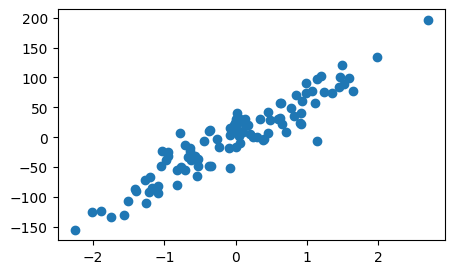

In [11]:
plt.figure(figsize=(5,3))
plt.scatter(x, y)

### Finding slope, and intercept using **OLS**

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
lr = LinearRegression()

In [14]:
lr.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
print(f'Slope: {lr.coef_}')
print(f'Intercept: {lr.intercept_}')

Slope: [62.61821599]
Intercept: 1.0082897291271335


### Defining our GDRegression class

In [16]:
m = 62.6182

In [94]:
class GDRegression:
    def __init__(self, m, b=0, learn_rate=0.01, epoches=100):
        self.m = m
        self.b = b
        self.learn_rate = learn_rate
        self.epoches = epoches

    def fit(self, x, y):
        for _ in range(self.epoches):
            slope_loss = -2 * np.sum(y - self.m*x.ravel() - self.b)
            step_size = self.learn_rate * slope_loss
            self.b = self.b - step_size

    def predict(self, x):
        return np.array([self.m*x.ravel() + self.b])

### Testing our class

In [95]:
gd_lr = GDRegression(m, 0, 0.001, 100)
gd_lr.fit(x, y)
gd_lr.b

np.float64(1.0082895781994639)

In [109]:
gd_lr.predict(x)[0, :10]

array([-43.42795023,   4.92839168, -21.75209967, -22.75264592,
       -58.79561391,  59.42363817, 125.61466394,  91.51575676,
       -31.82292243,  -5.22168259])